# 06 — Collaborative Filtering

This notebook implements two classic memory-based collaborative filtering approaches:

| Approach | Description |
|---|---|
| **User-Based CF** | Find users with similar taste → recommend what they liked |
| **Item-Based CF** | Find movies similar to ones the user already rated |

Both rely on the **user-item ratings matrix** built from `ratings_train.parquet`.

**Sections**
1. Setup & data loading
2. Build sparse user-item matrix
3. User-based CF
4. Item-based CF
5. Evaluation — RMSE & MAE on validation split
6. Cold-start fallback strategy
7. Save artefacts

## Section 1 — Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
import joblib, pickle, time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

PROCESSED = Path('../../data_science/processed')
MODELS    = Path('../../models')
MODELS.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MOVIELENS = Path('../../data/movielens')

# ── Load ratings ──────────────────────────────────────────────────────────────
print('Loading ratings_train …', end=' ')
ratings_train = pd.read_parquet(PROCESSED / 'ratings_train.parquet',
                                 columns=['userId', 'movieId', 'rating'])
print(f'{len(ratings_train):,} rows')

print('Loading ratings_val   …', end=' ')
ratings_val = pd.read_parquet(PROCESSED / 'ratings_val.parquet',
                               columns=['userId', 'movieId', 'rating'])
print(f'{len(ratings_val):,} rows')

# ── Load links.csv → movieId ↔ tmdb_id bridge ─────────────────────────────────
# master_movies uses tmdb_id; ratings use movieId (MovieLens ID).
# links.csv provides the mapping between the two ID spaces.
print('Loading links.csv      …', end=' ')
links = pd.read_csv(MOVIELENS / 'links.csv', dtype={'imdbId': str})
links['tmdb_id'] = pd.to_numeric(links['tmdbId'], errors='coerce').astype('Int64')
links = links.dropna(subset=['tmdb_id'])[['movieId', 'tmdb_id']].drop_duplicates(subset='movieId')
print(f'{len(links):,} rows')

# ── Load master_movies → get titles and quality scores ────────────────────────
print('Loading master_movies  …', end=' ')
master = pd.read_parquet(PROCESSED / 'master_movies.parquet',
                          columns=['tmdb_id', 'title', 'bayesian_score', 'tmdb_votes'])
master['tmdb_id'] = master['tmdb_id'].astype('Int64')
print(f'{len(master):,} rows')

# ── Build a movieId → title/bayesian_score lookup ─────────────────────────────
movies = links.merge(master, on='tmdb_id', how='left')
print(f'movies lookup: {len(movies):,} rows  title coverage: '
      f'{movies["title"].notna().sum():,}')

print()
print('Train rating range:', ratings_train['rating'].min(), '–', ratings_train['rating'].max())
print('Unique users  (train):', ratings_train['userId'].nunique())
print('Unique movies (train):', ratings_train['movieId'].nunique())

Loading ratings_train … 20,720,316 rows
Loading ratings_val   … 1,913,720 rows
Loading links.csv      … 45,624 rows
Loading master_movies  … 45,433 rows
movies lookup: 45,624 rows  title coverage: 45,460

Train rating range: 0.5 – 5.0
Unique users  (train): 226499
Unique movies (train): 24844


## Section 2 — Build Sparse User-Item Matrix

With ~20 M ratings, a dense matrix would be ~7 GB. We use `scipy.sparse.csr_matrix` instead.

We also define integer **index maps** so rows ↔ userId and columns ↔ movieId.

In [5]:
# ── Integer index maps ────────────────────────────────────────────────────────
user_ids  = ratings_train['userId'].unique()
movie_ids = ratings_train['movieId'].unique()

user2idx  = {uid: i for i, uid in enumerate(user_ids)}
movie2idx = {mid: j for j, mid in enumerate(movie_ids)}
idx2movie = {j: mid for mid, j in movie2idx.items()}
idx2user  = {i: uid for uid, i in user2idx.items()}

n_users  = len(user2idx)
n_movies = len(movie2idx)
print(f'Matrix shape: {n_users:,} users × {n_movies:,} movies')

# ── Build CSR matrix (users × movies) ────────────────────────────────────────
rows = ratings_train['userId'].map(user2idx).values
cols = ratings_train['movieId'].map(movie2idx).values
data = ratings_train['rating'].astype(np.float32).values

user_item = sp.csr_matrix((data, (rows, cols)), shape=(n_users, n_movies), dtype=np.float32)
item_user = user_item.T.tocsr()   # movies × users — for item-based CF

mem_mb = (user_item.data.nbytes + user_item.indices.nbytes + user_item.indptr.nbytes) / 1e6
density = user_item.nnz / (n_users * n_movies) * 100
print(f'CSR matrix: {mem_mb:.1f} MB, density {density:.4f}%')

Matrix shape: 226,499 users × 24,844 movies
CSR matrix: 166.7 MB, density 0.3682%


## Section 3 — User-Based Collaborative Filtering

**Algorithm**
1. Represent the query user as a sparse rating vector.
2. Compute cosine similarity against all other user vectors.
3. Pick the top-K most similar users (`neighbourhood`).
4. For each unseen movie, predict rating as a **weighted mean** of neighbour ratings (weighted by similarity).
5. Return top-N highest predicted-rating movies.

Cosine similarity naturally handles the sparsity — users with no co-rated movies get similarity 0.

In [9]:
def user_based_cf(user_id, n_recs=10, n_neighbours=50):
    """
    Return top-n_recs unseen movie IDs for user_id using user-based CF.

    Parameters
    ----------
    user_id      : int — query user
    n_recs       : int — number of movies to recommend
    n_neighbours : int — size of the neighbour pool

    Returns
    -------
    DataFrame with columns [movieId, predicted_rating, title]
    """
    if user_id not in user2idx:
        return pd.DataFrame(columns=['movieId', 'predicted_rating', 'title'])

    u_idx    = user2idx[user_id]
    user_vec = user_item[u_idx]                        # (1, n_movies) sparse

    # Cosine similarity between query user and ALL other users
    sims = cosine_similarity(user_vec, user_item).flatten()   # shape (n_users,)
    sims[u_idx] = 0.0                                   # exclude the user itself

    # Pick top-K neighbours (highest cosine similarity)
    top_n_idx = np.argpartition(sims, -n_neighbours)[-n_neighbours:]
    top_n_idx = top_n_idx[np.argsort(sims[top_n_idx])[::-1]]  # sorted desc
    top_sims  = sims[top_n_idx]                         # shape (n_neighbours,)

    if top_sims.sum() == 0:
        return pd.DataFrame(columns=['movieId', 'predicted_rating', 'title'])

    # Weighted sum of neighbour ratings for each movie
    neighbour_ratings = user_item[top_n_idx]           # (n_neighbours, n_movies)
    nbr_dense = neighbour_ratings.toarray()            # (n_neighbours, n_movies)
    w = top_sims[:, np.newaxis]                        # (n_neighbours, 1)
    weighted_sum  = (w * nbr_dense).sum(axis=0)        # (n_movies,)
    weight_denom  = (w * (nbr_dense > 0)).sum(axis=0)  # (n_movies,)
    with np.errstate(divide='ignore', invalid='ignore'):
        pred_ratings = np.where(weight_denom > 0, weighted_sum / weight_denom, 0.0)

    # Mask movies the user has already rated
    already_rated = user_vec.indices
    pred_ratings[already_rated] = 0.0

    top_movies = np.argpartition(pred_ratings, -n_recs)[-n_recs:]
    top_movies = top_movies[np.argsort(pred_ratings[top_movies])[::-1]]

    result_mids   = [idx2movie[j] for j in top_movies]
    result_scores = pred_ratings[top_movies]

    rec_df = pd.DataFrame({'movieId': result_mids, 'predicted_rating': result_scores})
    rec_df = rec_df.merge(movies[['movieId', 'title']].dropna(), on='movieId', how='left')
    return rec_df

print('user_based_cf() defined.')

user_based_cf() defined.


In [10]:
# ── Demo: pick a user with many ratings ──────────────────────────────────────
user_counts = ratings_train.groupby('userId').size()
sample_user = int(user_counts[user_counts >= 200].index[0])

print(f'Demo user: {sample_user}  (rated {user_counts[sample_user]} movies in train)')

t0 = time.perf_counter()
ubcf_recs = user_based_cf(sample_user, n_recs=10, n_neighbours=50)
ms = (time.perf_counter() - t0) * 1000

print(f'Recommendations ({ms:.0f} ms):')
print(ubcf_recs[['title', 'predicted_rating']].to_string(index=False))

Demo user: 11  (rated 227 movies in train)
Recommendations (332 ms):
                   title  predicted_rating
The Secret in Their Eyes               5.0
        Sigur Rós: Heima               5.0
       Girl, Interrupted               5.0
        Internal Affairs               5.0
             John Carter               5.0
              The Return               5.0
    Strangers on a Train               5.0
        Eyes of an Angel               5.0
             Wonder Boys               5.0
         Bicycle Thieves               5.0


## Section 4 — Item-Based Collaborative Filtering

**Algorithm**
1. For a query user, collect their rated movies and ratings.
2. For each rated movie, compute cosine similarity (column ↔ column in `user_item`) against all other movies.
3. Aggregate similarity-weighted scores across all rated movies → predicted affinity per unseen movie.
4. Return top-N.

Item-based CF is generally more stable than user-based CF because items change less frequently than user preferences.

In [13]:
def item_based_cf(user_id, n_recs=10, n_similar=30):
    """
    Return top-n_recs unseen movie IDs for user_id using item-based CF.

    Parameters
    ----------
    user_id    : int — query user
    n_recs     : int — number of movies to recommend
    n_similar  : int — top-K similar items to consider per rated movie

    Returns
    -------
    DataFrame with columns [movieId, predicted_rating, title]
    """
    if user_id not in user2idx:
        return pd.DataFrame(columns=['movieId', 'predicted_rating', 'title'])

    u_idx      = user2idx[user_id]
    user_vec   = user_item[u_idx]                # (1, n_movies) sparse CSR
    rated_cols = user_vec.indices                # int array: col indices user rated
    # user_vec.data gives the non-zero rating values directly (no sparse slice needed)
    rated_vals = user_vec.data.astype(np.float64)  # 1-D float array

    if len(rated_cols) == 0:
        return pd.DataFrame(columns=['movieId', 'predicted_rating', 'title'])

    # Score accumulators
    score_num = np.zeros(n_movies, dtype=np.float64)
    score_den = np.zeros(n_movies, dtype=np.float64)

    # Compute cosine similarity of all rated items vs all items in one matrix call
    rated_vecs  = item_user[rated_cols]            # (len_rated, n_users) sparse
    sims_block  = cosine_similarity(rated_vecs, item_user)  # (len_rated, n_movies) dense

    for k in range(len(rated_cols)):
        sim_row     = sims_block[k].copy()         # (n_movies,) float64
        sim_row[rated_cols[k]] = 0.0               # exclude self-similarity
        r_ui        = float(rated_vals[k])

        # Take top n_similar neighbours by similarity
        top_idx = np.argpartition(sim_row, -n_similar)[-n_similar:]
        top_sim = sim_row[top_idx]                 # (n_similar,) 1-D array

        score_num[top_idx] += top_sim * r_ui
        score_den[top_idx] += top_sim

    with np.errstate(divide='ignore', invalid='ignore'):
        pred = np.where(score_den > 0, score_num / score_den, 0.0)

    # Mask already-rated movies
    pred[rated_cols] = 0.0

    top_movies = np.argpartition(pred, -n_recs)[-n_recs:]
    top_movies = top_movies[np.argsort(pred[top_movies])[::-1]]

    result_mids   = [idx2movie[j] for j in top_movies]
    result_scores = pred[top_movies]

    rec_df = pd.DataFrame({'movieId': result_mids, 'predicted_rating': result_scores})
    rec_df = rec_df.merge(movies[['movieId', 'title']].dropna(), on='movieId', how='left')
    return rec_df

print('item_based_cf() defined.')

item_based_cf() defined.


In [14]:
# ── Demo: same user, item-based CF ───────────────────────────────────────────
t0 = time.perf_counter()
ibcf_recs = item_based_cf(sample_user, n_recs=10, n_similar=30)
ms = (time.perf_counter() - t0) * 1000

print(f'Item-based CF for user {sample_user}  ({ms:.0f} ms):')
print(ibcf_recs[['title', 'predicted_rating']].to_string(index=False))

# Overlap between user-based and item-based recommendations
ubcf_set = set(ubcf_recs['movieId'])
ibcf_set = set(ibcf_recs['movieId'])
overlap  = ubcf_set & ibcf_set
print(f'\nOverlap between UBCF and IBCF top-10: {len(overlap)} movies')

Item-based CF for user 11  (1299 ms):
                      title  predicted_rating
         X-Men: First Class               5.0
                Source Code               5.0
      The Dark Knight Rises               5.0
     The Man Without a Past               4.5
Sympathy for Lady Vengeance               4.5
         The Brothers Bloom               4.5
                       Kops               4.5
               Show Me Love               4.5
             Starter for 10               4.5
                   Together               4.5

Overlap between UBCF and IBCF top-10: 0 movies


## Section 5 — Evaluation: RMSE & MAE on Validation Set

We evaluate **rating prediction** accuracy, not just ranking quality.

**Protocol**
- Select users who have ≥ 50 ratings in train and ≥ 5 ratings in val.
- For each qualifying user, predict ratings for their val movies using UBCF and IBCF.
- Compute RMSE and MAE vs actual val ratings.
- Fallback: if no prediction is available (cold item), use the global mean rating.

We sample 200 users for efficiency.

In [15]:
# ── Build evaluation user pool ────────────────────────────────────────────────
train_counts = ratings_train.groupby('userId').size().rename('train_count')
val_counts   = ratings_val.groupby('userId').size().rename('val_count')

eval_users_df = pd.concat([train_counts, val_counts], axis=1).dropna()
eval_users_df = eval_users_df[(eval_users_df['train_count'] >= 50) &
                               (eval_users_df['val_count']   >= 5)]

print(f'Qualifying users: {len(eval_users_df):,}')

np.random.seed(42)
EVAL_N = min(200, len(eval_users_df))
eval_users = eval_users_df.sample(EVAL_N, random_state=42).index.tolist()
print(f'Sampled {EVAL_N} users for evaluation.')

# Global mean for cold-item fallback
global_mean = float(ratings_train['rating'].mean())
print(f'Global mean rating: {global_mean:.4f}')

Qualifying users: 2,889
Sampled 200 users for evaluation.
Global mean rating: 3.5212


In [18]:
def predict_ratings_ubcf(user_id, target_movie_ids, n_neighbours=50):
    """Return dict {movieId: predicted_rating} for target_movie_ids."""
    if user_id not in user2idx:
        return {m: global_mean for m in target_movie_ids}

    u_idx    = user2idx[user_id]
    user_vec = user_item[u_idx]
    sims     = cosine_similarity(user_vec, user_item).flatten()
    sims[u_idx] = 0.0

    top_n_idx = np.argpartition(sims, -n_neighbours)[-n_neighbours:]
    top_sims  = sims[top_n_idx]

    preds = {}
    for mid in target_movie_ids:
        if mid not in movie2idx:
            preds[mid] = global_mean
            continue
        j         = movie2idx[mid]
        nbr_rtgs  = user_item[top_n_idx, j].toarray().flatten()
        non_zero  = nbr_rtgs > 0
        if non_zero.sum() == 0:
            preds[mid] = global_mean
        else:
            w   = top_sims[non_zero]
            preds[mid] = float(np.dot(w, nbr_rtgs[non_zero]) / w.sum()) if w.sum() > 0 else global_mean
    return preds


def predict_ratings_ibcf(user_id, target_movie_ids, n_similar=30):
    """Return dict {movieId: predicted_rating} for target_movie_ids."""
    if user_id not in user2idx:
        return {m: global_mean for m in target_movie_ids}

    u_idx      = user2idx[user_id]
    user_vec   = user_item[u_idx]
    rated_cols = user_vec.indices
    # Use .data directly to get a plain 1-D float array of the user's known ratings
    rated_vals = user_vec.data.astype(np.float64)

    if len(rated_cols) == 0:
        return {m: global_mean for m in target_movie_ids}

    rated_vecs  = item_user[rated_cols]                   # (len_rated, n_users)

    preds = {}
    for mid in target_movie_ids:
        if mid not in movie2idx:
            preds[mid] = global_mean
            continue
        j        = movie2idx[mid]
        tgt_vec  = item_user[j]                           # (1, n_users)
        sims_row = cosine_similarity(rated_vecs, tgt_vec).flatten()  # (len_rated,)

        # Weighted average of user's known ratings, weighted by item-item similarity
        total_sim = float(sims_row.sum())
        if total_sim == 0:
            preds[mid] = global_mean
        else:
            preds[mid] = float(np.dot(sims_row, rated_vals) / total_sim)
    return preds


print('Rating prediction functions defined.')

Rating prediction functions defined.


In [19]:
# ── Evaluation loop ───────────────────────────────────────────────────────────
# Build val lookup: userId → {movieId: actual_rating}
val_lookup = ratings_val.groupby('userId').apply(
    lambda g: dict(zip(g['movieId'], g['rating']))
).to_dict()

ubcf_errors, ibcf_errors = [], []
processed = 0

start = time.perf_counter()
for uid in eval_users:
    if uid not in val_lookup:
        continue
    val_items  = list(val_lookup[uid].keys())
    actuals    = np.array([val_lookup[uid][m] for m in val_items], dtype=np.float32)

    # UBCF predictions
    ubcf_preds = predict_ratings_ubcf(uid, val_items)
    ubcf_pred_arr = np.array([ubcf_preds[m] for m in val_items], dtype=np.float32)

    # IBCF predictions
    ibcf_preds = predict_ratings_ibcf(uid, val_items)
    ibcf_pred_arr = np.array([ibcf_preds[m] for m in val_items], dtype=np.float32)

    ubcf_errors.append((actuals, ubcf_pred_arr))
    ibcf_errors.append((actuals, ibcf_pred_arr))
    processed += 1

    if processed % 20 == 0:
        elapsed = time.perf_counter() - start
        print(f'  … {processed}/{EVAL_N} users done ({elapsed:.1f}s)')

total_time = time.perf_counter() - start
print(f'Evaluation complete. {processed} users, {total_time:.1f}s total.')

# ── Aggregate errors ──────────────────────────────────────────────────────────
def aggregate_errors(errors):
    all_actual = np.concatenate([a for a, _ in errors])
    all_pred   = np.concatenate([p for _, p in errors])
    rmse = float(np.sqrt(np.mean((all_actual - all_pred) ** 2)))
    mae  = float(np.mean(np.abs(all_actual - all_pred)))
    return rmse, mae

ubcf_rmse, ubcf_mae = aggregate_errors(ubcf_errors)
ibcf_rmse, ibcf_mae = aggregate_errors(ibcf_errors)

print()
print(f'{'Method':<20} {'RMSE':>8} {'MAE':>8}')
print('-' * 40)
print(f'{'User-Based CF':<20} {ubcf_rmse:>8.4f} {ubcf_mae:>8.4f}')
print(f'{'Item-Based CF':<20} {ibcf_rmse:>8.4f} {ibcf_mae:>8.4f}')

  … 20/200 users done (91.3s)
  … 40/200 users done (159.7s)
  … 60/200 users done (242.7s)
  … 80/200 users done (290.1s)
  … 100/200 users done (333.5s)
  … 120/200 users done (385.8s)
  … 140/200 users done (427.0s)
  … 160/200 users done (499.0s)
  … 180/200 users done (560.1s)
  … 200/200 users done (644.3s)
Evaluation complete. 200 users, 644.3s total.

Method                   RMSE      MAE
----------------------------------------
User-Based CF          0.9653   0.7230
Item-Based CF          0.9647   0.7175


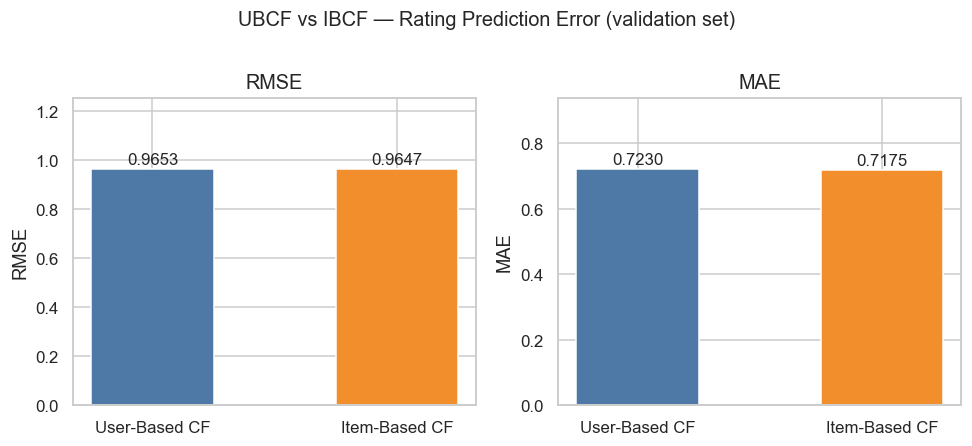

In [20]:
# ── Evaluation comparison bar chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

methods  = ['User-Based CF', 'Item-Based CF']
rmse_vals = [ubcf_rmse, ibcf_rmse]
mae_vals  = [ubcf_mae,  ibcf_mae]
colors    = ['#4e79a7', '#f28e2b']

for ax, vals, metric in zip(axes, [rmse_vals, mae_vals], ['RMSE', 'MAE']):
    bars = ax.bar(methods, vals, color=colors, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=11)
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.set_ylabel(metric)

plt.suptitle('UBCF vs IBCF — Rating Prediction Error (validation set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Section 6 — Cold-Start Fallback Strategy

| Scenario | Problem | Fallback |
|---|---|---|
| **New user** (no ratings) | No rating vector → can't compute user similarity | Serve trending / highly-rated movies using `bayesian_score` |
| **New movie** (few/no ratings) | Not in `user_item` matrix → no item similarity | Fall back to content-based (TF-IDF cosine from NB05) |

Below we implement both fallbacks.

In [21]:
# ── Cold-start: new user → popularity fallback ────────────────────────────────
def cold_start_popular(n_recs=10, min_votes=200):
    """Return top-n_recs movies by bayesian_score for brand-new users."""
    candidates = movies.dropna(subset=['bayesian_score', 'movieId'])
    candidates = candidates[candidates['tmdb_votes'] >= min_votes]
    top = candidates.nlargest(n_recs, 'bayesian_score')[['title', 'bayesian_score', 'movieId']]
    return top.reset_index(drop=True)


# ── Cold-start: new item → content-based fallback ─────────────────────────────
def cold_start_content(title, n_recs=10):
    """
    Return content-based recommendations using saved TF-IDF artefacts (NB05).
    Falls back gracefully if artefacts are not present.
    """
    tfidf_path  = MODELS / 'tfidf_matrix.npz'
    idx_path    = MODELS / 'title_to_idx.pkl'

    if not (tfidf_path.exists() and idx_path.exists()):
        print('Content-based artefacts not found. Run 05_content_based.ipynb first.')
        return pd.DataFrame(columns=['title', 'score'])

    from sklearn.metrics.pairwise import linear_kernel
    tfidf_matrix = sp.load_npz(tfidf_path)
    with open(idx_path, 'rb') as f:
        title_to_idx = pickle.load(f)

    key = title.lower().strip()
    if key not in title_to_idx:
        print(f'Title not found: "{title}"')
        return pd.DataFrame(columns=['title', 'score'])

    raw_idx = title_to_idx[key]
    idx     = int(raw_idx.iloc[0]) if hasattr(raw_idx, 'iloc') else int(raw_idx)

    query_vec  = tfidf_matrix[idx]
    cos_scores = linear_kernel(query_vec, tfidf_matrix).flatten()
    cos_scores[idx] = 0.0

    top_idx = np.argpartition(cos_scores, -n_recs)[-n_recs:]
    top_idx = top_idx[np.argsort(cos_scores[top_idx])[::-1]]

    # Reload master_movies titles (indexed by row position)
    master_titles = pd.read_parquet(PROCESSED / 'master_movies.parquet', columns=['title'])
    result = pd.DataFrame({'title': master_titles.iloc[top_idx]['title'].values,
                           'score': cos_scores[top_idx]})
    return result


print('Cold-start fallbacks defined.')
print('\n— Popular movies for new users —')
print(cold_start_popular(10).to_string(index=False))

print('\n— Content-based for new/unknown item: "Inception" —')
print(cold_start_content('Inception', 10).to_string(index=False))

Cold-start fallbacks defined.

— Popular movies for new users —
                                            title  bayesian_score  movieId
                         The Shawshank Redemption          9.2999      318
                                    The Godfather          9.1999      858
                                  The Dark Knight          9.0999    58559
    The Lord of the Rings: The Return of the King          8.9999     7153
                                 Schindler's List          8.9998      527
                           The Godfather: Part II          8.9998     1221
                                     12 Angry Men          8.9997     1203
The Lord of the Rings: The Fellowship of the Ring          8.8999     4993
                                     Pulp Fiction          8.7999      296
                                     Forrest Gump          8.7999      356

— Content-based for new/unknown item: "Inception" —
         title    score
       Don Jon 0.180485
         B

## Section 7 — Save Artefacts

| Artefact | Purpose |
|---|---|
| `user_item_matrix.npz` | Sparse user-item ratings matrix |
| `item_user_matrix.npz` | Transpose — for item-based CF |
| `user_id_map.pkl` | userId → row index |
| `movie_id_map.pkl` | movieId → column index |
| `eval_metrics.pkl` | UBCF / IBCF RMSE & MAE |

The matrices are in CSR format (scipy sparse) which is fast for row-slice operations needed in CF.

In [22]:
# ── Save artefacts ────────────────────────────────────────────────────────────
sp.save_npz(MODELS / 'user_item_matrix.npz', user_item)
print(f'Saved: user_item_matrix.npz  {(MODELS / "user_item_matrix.npz").stat().st_size / 1e6:.1f} MB')

sp.save_npz(MODELS / 'item_user_matrix.npz', item_user)
print(f'Saved: item_user_matrix.npz  {(MODELS / "item_user_matrix.npz").stat().st_size / 1e6:.1f} MB')

with open(MODELS / 'user_id_map.pkl', 'wb') as f:
    pickle.dump({'user2idx': user2idx, 'idx2user': idx2user}, f)
print('Saved: user_id_map.pkl')

with open(MODELS / 'movie_id_map.pkl', 'wb') as f:
    pickle.dump({'movie2idx': movie2idx, 'idx2movie': idx2movie}, f)
print('Saved: movie_id_map.pkl')

metrics = {
    'ubcf_rmse': ubcf_rmse, 'ubcf_mae': ubcf_mae,
    'ibcf_rmse': ibcf_rmse, 'ibcf_mae': ibcf_mae,
    'eval_users': EVAL_N,
    'global_mean': global_mean
}
with open(MODELS / 'cf_eval_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)
print('Saved: cf_eval_metrics.pkl')

print('\nAll CF artefacts saved to models/')

Saved: user_item_matrix.npz  45.3 MB
Saved: item_user_matrix.npz  48.1 MB
Saved: user_id_map.pkl
Saved: movie_id_map.pkl
Saved: cf_eval_metrics.pkl

All CF artefacts saved to models/
